# SECTION 1 — LIBRARY IMPORTS

In [58]:
# ============================================
# STARTUP SUCCESS PREDICTION PROJECT
# SECTION 1 : LIBRARY IMPORTS
# ============================================

# Basic Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn Utilities
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# XGBoost
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    mean_squared_error
)

# Model Saving
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

#sklearn StackingClassifier
from sklearn.ensemble import StackingClassifier


print("All libraries imported successfully.")

All libraries imported successfully.


# SECTION 2 — LOAD DATASET

In [59]:
# ============================================
# SECTION 2 : LOAD DATASET
# ============================================

# Upload CSV manually in Colab first

df = pd.read_csv('startup_data.csv')

print("Dataset Loaded Successfully\n")

print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
display(df.head())

Dataset Loaded Successfully

Dataset Shape:
(923, 49)

First 5 Rows:


,Unnamed: 0,state_code,latitude,longitude,zip_code,id,city,Unnamed: 6,name,labels,...,object_id,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants,is_top500,status
0,1005,CA,42.358880,-71.056820,92101,c:6669,San Diego,NaN,Bandsintown,1,...,c:6669,0,1,0,0,0,0,1.0000,0,acquired
1,204,CA,37.238916,-121.973718,95032,c:16283,Los Gatos,NaN,TriCipher,1,...,c:16283,1,0,0,1,1,1,4.7500,1,acquired
2,1001,CA,32.901049,-117.192656,92121,c:65620,San Diego,San Diego CA 92121,Plixi,1,...,c:65620,0,0,1,0,0,0,4.0000,1,acquired
3,738,CA,37.320309,-122.050040,95014,c:42668,Cupertino,Cupertino CA 95014,Solidcore Systems,1,...,c:42668,0,0,0,1,1,1,3.3333,1,acquired
4,1002,CA,37.779281,-122.419236,94105,c:65806,San Francisco,San Francisco CA 94105,Inhale Digital,0,...,c:65806,1,1,0,0,0,0,1.0000,1,closed


# SECTION 3 — BASIC DATA EXPLORATION

In [60]:
# ============================================
# SECTION 3 : BASIC EXPLORATION
# ============================================

print("\nDataset Info:\n")
print(df.info())

print("\nMissing Values:\n")
print(df.isnull().sum().sort_values(ascending=False))

print("\nTarget Distribution:\n")
print(df['status'].value_counts())

print("\nStatistical Summary:\n")
display(df.describe())


Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 923 entries, 0 to 922
Data columns (total 49 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                923 non-null    int64  
 1   state_code                923 non-null    object 
 2   latitude                  923 non-null    float64
 3   longitude                 923 non-null    float64
 4   zip_code                  923 non-null    object 
 5   id                        923 non-null    object 
 6   city                      923 non-null    object 
 7   Unnamed: 6                430 non-null    object 
 8   name                      923 non-null    object 
 9   labels                    923 non-null    int64  
 10  founded_at                923 non-null    object 
 11  closed_at                 335 non-null    object 
 12  first_funding_at          923 non-null    object 
 13  last_funding_at           923 non-null    object 

,Unnamed: 0,latitude,longitude,labels,age_first_funding_year,age_last_funding_year,age_first_milestone_year,age_last_milestone_year,relationships,funding_rounds,...,is_consulting,is_othercategory,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants,is_top500
count,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,771.000000,771.000000,923.000000,923.000000,...,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000
mean,572.297941,38.517442,-103.539212,0.646804,2.235630,3.931456,3.055353,4.754423,7.710726,2.310943,...,0.003250,0.322860,0.326111,0.254605,0.508126,0.392199,0.232936,0.099675,2.838586,0.809317
std,333.585431,3.741497,22.394167,0.478222,2.510449,2.967910,2.977057,3.212107,7.265776,1.390922,...,0.056949,0.467823,0.469042,0.435875,0.500205,0.488505,0.422931,0.299729,1.874601,0.393052
min,1.000000,25.752358,-122.756956,0.000000,-9.046600,-9.046600,-14.169900,-7.005500,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,283.500000,37.388869,-122.198732,0.000000,0.576700,1.669850,1.000000,2.411000,3.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.500000,1.000000
50%,577.000000,37.779281,-118.374037,1.000000,1.446600,3.528800,2.520500,4.476700,5.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,2.500000,1.000000
75%,866.500000,40.730646,-77.214731,1.000000,3.575350,5.560250,4.686300,6.753400,10.000000,3.000000,...,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,3.800000,1.000000
max,1153.000000,59.335232,18.057121,1.000000,21.895900,21.895900,24.684900,24.684900,63.000000,10.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,16.000000,1.000000


# SECTION 4 — DATA CLEANING

In [62]:
# ============================================
# SECTION 4 : DATA CLEANING
# ============================================

# Create a copy
data = df.copy()

# --------------------------------------------
# DROP USELESS COLUMNS
# --------------------------------------------

drop_columns = [
    'Unnamed: 0',
    'Unnamed: 6',
    'id',
    'object_id',
    'zip_code',
    'name',
    'city',
    'state_code',
    'state_code.1',
    'closed_at',
    'founded_at',
    'first_funding_at',
    'last_funding_at',
    'category_code',   # ADD THIS cause string and labeling already kora
    'labels'   # ADD THIS (Target Leakage)
]

data.drop(columns=drop_columns, inplace=True)

print("Columns dropped successfully.")

# --------------------------------------------
# HANDLE MISSING VALUES
# --------------------------------------------

# Fill milestone missing values with median
data['age_first_milestone_year'].fillna(
    data['age_first_milestone_year'].median(),
    inplace=True
)

data['age_last_milestone_year'].fillna(
    data['age_last_milestone_year'].median(),
    inplace=True
)

print("Missing values handled.")

# --------------------------------------------
# ENCODE TARGET VARIABLE
# acquired = 1
# closed = 0
# --------------------------------------------

data['status'] = data['status'].map({
    'acquired': 1,
    'closed': 0
})

print("\nTarget Encoding Done.")

print("\nRemaining Missing Values:")
print(data.isnull().sum().sum())

print("\nFinal Dataset Shape:")
print(data.shape)

Columns dropped successfully.
Missing values handled.

Target Encoding Done.

Remaining Missing Values:
0

Final Dataset Shape:
(923, 34)


# SECTION 5 — FEATURE ENGINEERING

In [63]:
# ============================================
# SECTION 5 : FEATURE ENGINEERING
# ============================================

# Funding per round
data['funding_per_round'] = (
    data['funding_total_usd'] /
    (data['funding_rounds'] + 1)
)

# Milestone efficiency
data['milestone_efficiency'] = (
    data['milestones'] /
    (data['relationships'] + 1)
)

# Investor score
data['investor_score'] = (
    data['has_VC'] +
    data['has_angel'] +
    data['has_roundA'] +
    data['has_roundB'] +
    data['has_roundC'] +
    data['has_roundD']
)

# Log transform funding
data['log_funding_total_usd'] = np.log1p(
    data['funding_total_usd']
)

print("Feature Engineering Completed.")

display(data.head())

Feature Engineering Completed.


,latitude,longitude,age_first_funding_year,age_last_funding_year,age_first_milestone_year,age_last_milestone_year,relationships,funding_rounds,funding_total_usd,milestones,...,has_roundB,has_roundC,has_roundD,avg_participants,is_top500,status,funding_per_round,milestone_efficiency,investor_score,log_funding_total_usd
0,42.358880,-71.056820,2.2493,3.0027,4.6685,6.7041,3,3,375000,3,...,0,0,0,1.0000,0,1,9.375000e+04,0.750000,1,12.834684
1,37.238916,-121.973718,5.1260,9.9973,7.0055,7.0055,9,4,40100000,1,...,1,1,1,4.7500,1,1,8.020000e+06,0.100000,4,17.506887
2,32.901049,-117.192656,1.0329,1.0329,1.4575,2.2055,5,1,2600000,2,...,0,0,0,4.0000,1,1,1.300000e+06,0.333333,1,14.771022
3,37.320309,-122.050040,3.1315,5.3151,6.0027,6.0027,5,3,40000000,1,...,1,1,1,3.3333,1,1,1.000000e+07,0.166667,3,17.504390
4,37.779281,-122.419236,0.0000,1.6685,0.0384,0.0384,2,2,1300000,1,...,0,0,0,1.0000,1,0,4.333333e+05,0.333333,2,14.077876


# SECTION 6 — EDA VISUALIZATION

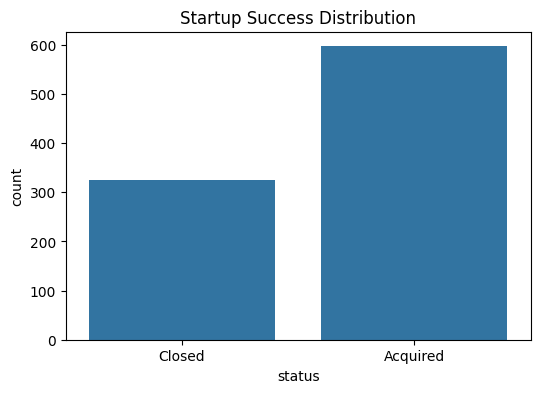

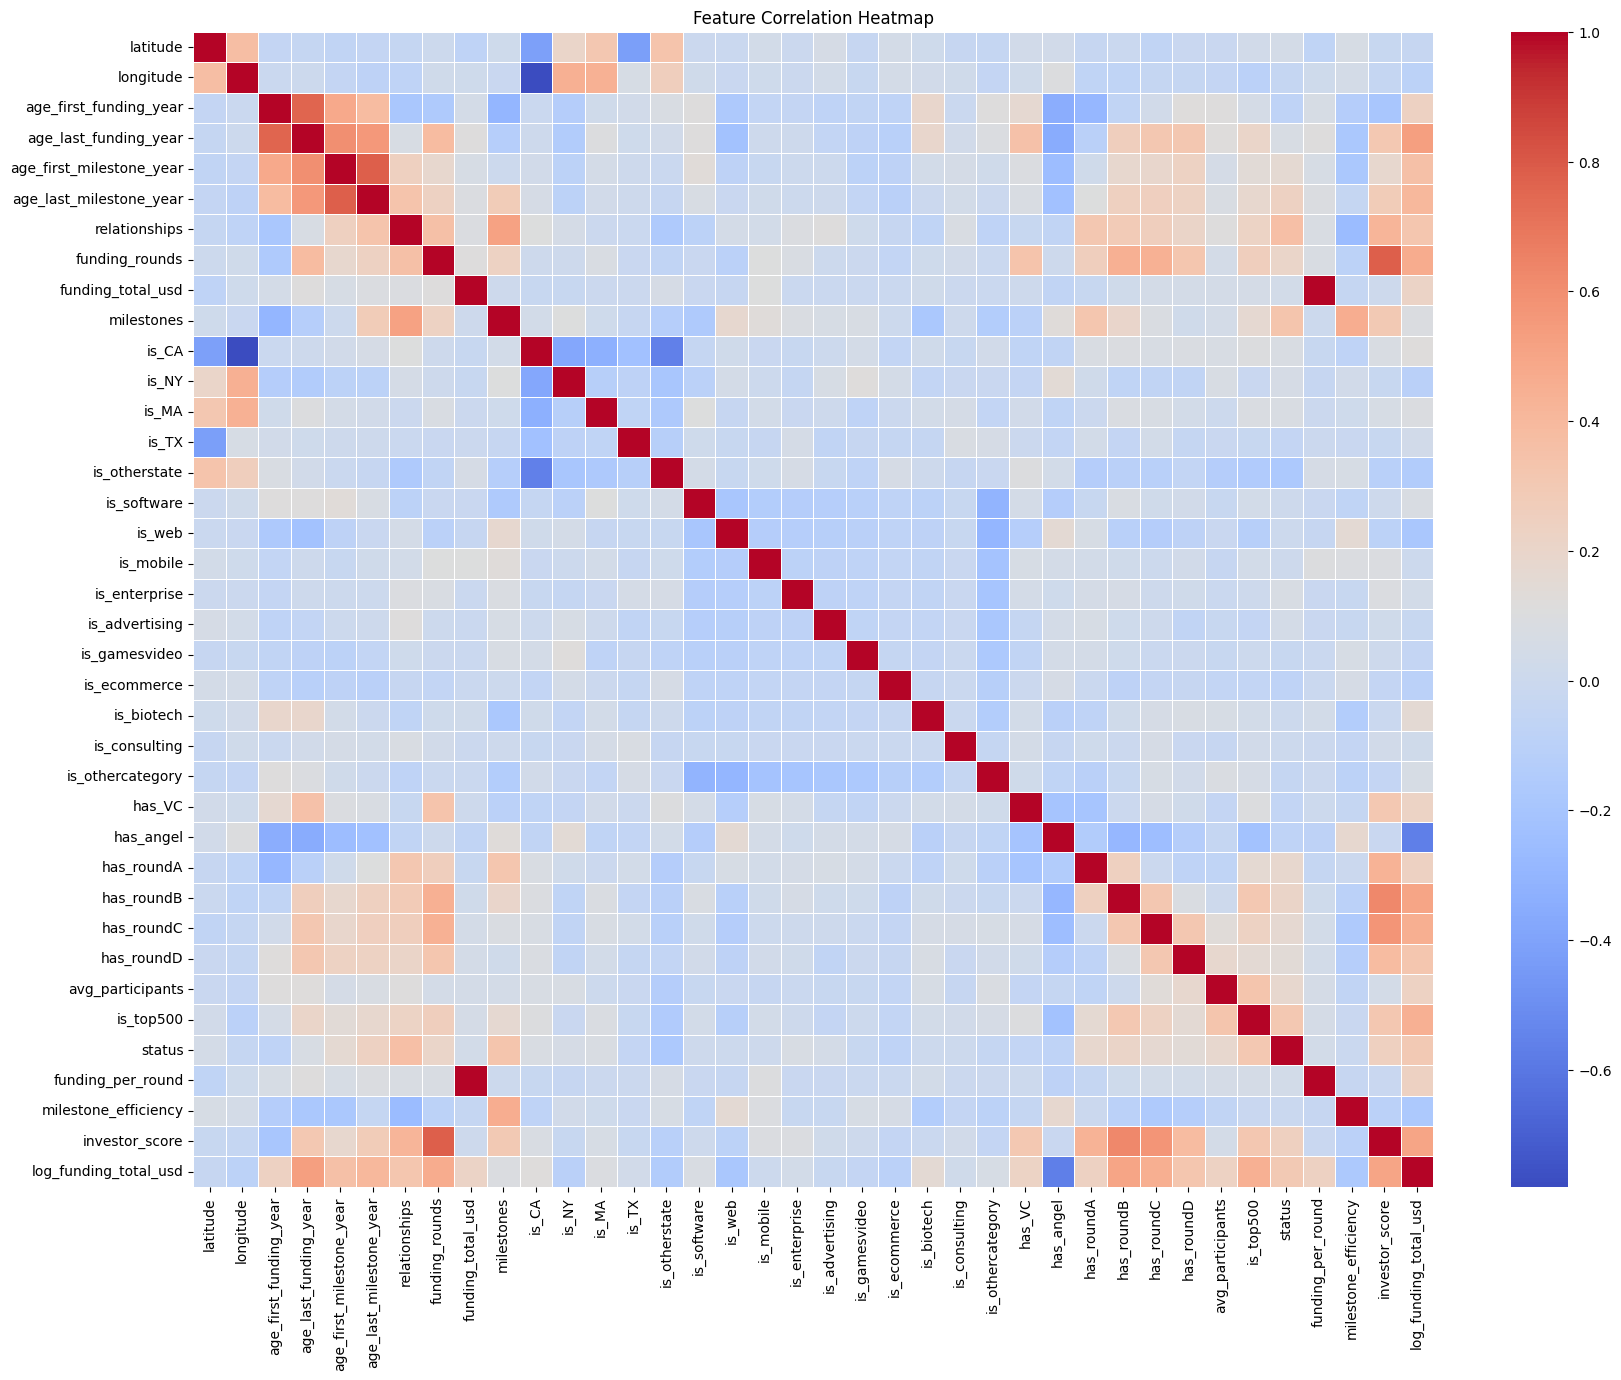

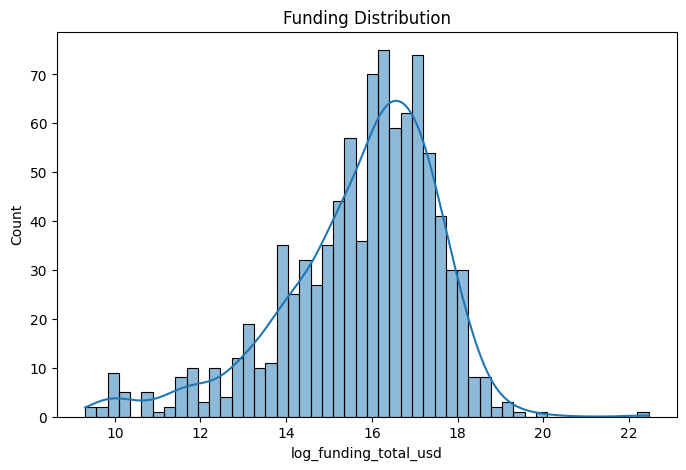

In [64]:
# ============================================
# SECTION 6 : EDA VISUALIZATION
# ============================================

# --------------------------------------------
# TARGET DISTRIBUTION
# --------------------------------------------

plt.figure(figsize=(6,4))

sns.countplot(x=data['status'])

plt.title("Startup Success Distribution")
plt.xticks([0,1], ['Closed', 'Acquired'])

plt.show()

# --------------------------------------------
# CORRELATION HEATMAP
# --------------------------------------------

plt.figure(figsize=(20,15))

# Select only numeric columns for correlation calculation
corr = data.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")

plt.show()

# --------------------------------------------
# FUNDING DISTRIBUTION
# --------------------------------------------

plt.figure(figsize=(8,5))

sns.histplot(
    data['log_funding_total_usd'],
    bins=50,
    kde=True
)

plt.title("Funding Distribution")

plt.show()

# SECTION 7 — TRAIN TEST SPLIT

In [65]:
# ============================================
# SECTION 7 : TRAIN TEST SPLIT
# ============================================

X = data.drop('status', axis=1)
y = data['status']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (738, 37)
Testing Shape: (185, 37)


# SECTION 8 — FEATURE SCALING

In [66]:
# ============================================
# SECTION 8 : FEATURE SCALING
# ============================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed.")

Feature Scaling Completed.


# SECTION 9 — CREATE RESULT STORAGE

In [67]:
# ============================================
# SECTION 9 : RESULT STORAGE
# ============================================

results = []

print("Result storage initialized.")

Result storage initialized.


# SECTION 10 — LOGISTIC REGRESSION

LOGISTIC REGRESSION RESULTS

Accuracy : 0.7027027027027027
Precision: 0.8421052631578947
Recall   : 0.6666666666666666
F1 Score : 0.7441860465116279
ROC AUC  : 0.7834615384615384
RMSE     : 0.5452497568062706

Classification Report:

              precision    recall  f1-score   support

           0       0.56      0.77      0.65        65
           1       0.84      0.67      0.74       120

    accuracy                           0.70       185
   macro avg       0.70      0.72      0.69       185
weighted avg       0.74      0.70      0.71       185



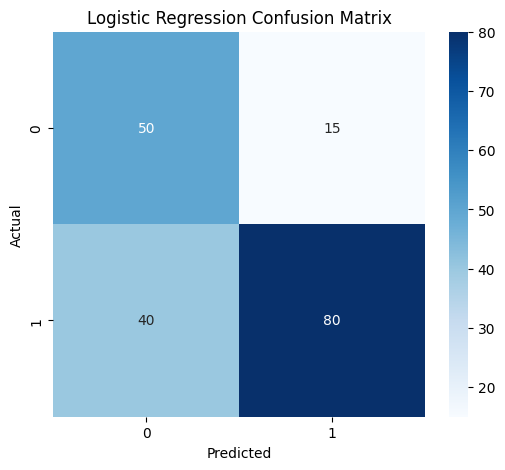

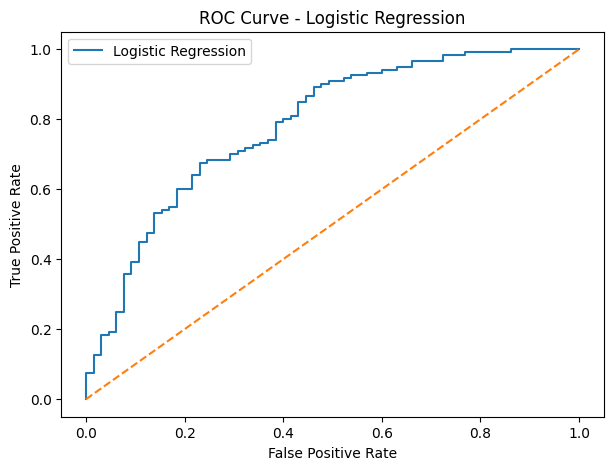

In [68]:
# ============================================
# SECTION 10 : LOGISTIC REGRESSION
# ============================================

# Create model
lr_model = LogisticRegression(
    max_iter=500,
    class_weight='balanced',
    random_state=42
)

# Train model
lr_model.fit(X_train_scaled, y_train)

# Predictions
lr_pred = lr_model.predict(X_test_scaled)

# Probabilities
lr_prob = lr_model.predict_proba(X_test_scaled)[:,1]

# Metrics
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_prob)

# RMSE
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

# Print results
print("LOGISTIC REGRESSION RESULTS\n")

print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)
print("ROC AUC  :", lr_auc)
print("RMSE     :", lr_rmse)

# Classification report
print("\nClassification Report:\n")

print(classification_report(y_test, lr_pred))

# Save results
results.append([
    'Logistic Regression',
    lr_accuracy,
    lr_precision,
    lr_recall,
    lr_f1,
    lr_auc,
    lr_rmse
])

# ============================================
# LOGISTIC REGRESSION CONFUSION MATRIX
# ============================================

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ============================================
# LOGISTIC REGRESSION ROC CURVE
# ============================================

fpr, tpr, thresholds = roc_curve(y_test, lr_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label='Logistic Regression')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()

# SECTION 11 — DECISION TREE

DECISION TREE RESULTS

Accuracy : 0.7027027027027027
Precision: 0.7876106194690266
Recall   : 0.7416666666666667
F1 Score : 0.7639484978540773
ROC AUC  : 0.7330128205128206
RMSE     : 0.5452497568062706

Classification Report:

              precision    recall  f1-score   support

           0       0.57      0.63      0.60        65
           1       0.79      0.74      0.76       120

    accuracy                           0.70       185
   macro avg       0.68      0.69      0.68       185
weighted avg       0.71      0.70      0.71       185



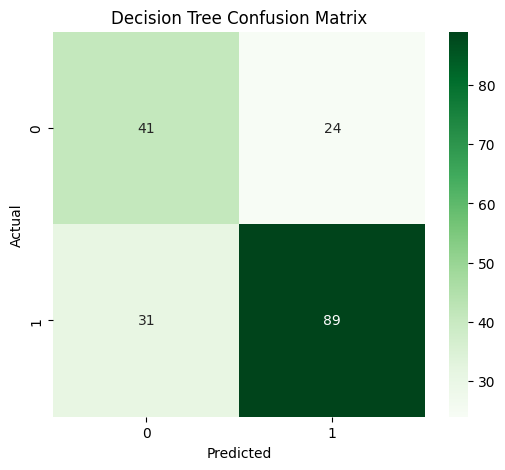

In [69]:
# ============================================
# SECTION 11 : DECISION TREE
# ============================================

dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42
)

# Train
dt_model.fit(X_train, y_train)

# Predict
dt_pred = dt_model.predict(X_test)

# Probabilities
dt_prob = dt_model.predict_proba(X_test)[:,1]

# Metrics
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)
dt_auc = roc_auc_score(y_test, dt_prob)

# RMSE
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))

# Print
print("DECISION TREE RESULTS\n")

print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)
print("ROC AUC  :", dt_auc)
print("RMSE     :", dt_rmse)

# Report
print("\nClassification Report:\n")

print(classification_report(y_test, dt_pred))

# Save results
results.append([
    'Decision Tree',
    dt_accuracy,
    dt_precision,
    dt_recall,
    dt_f1,
    dt_auc,
    dt_rmse
])

# ============================================
#DECISION TREE CONFUSION MATRIX
# ============================================
cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Decision Tree Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# SECTION 12 — RANDOM FOREST

RANDOM FOREST RESULTS

Accuracy : 0.7405405405405405
Precision: 0.7769230769230769
Recall   : 0.8416666666666667
F1 Score : 0.808
ROC AUC  : 0.8342307692307692
RMSE     : 0.5093716319736107

Classification Report:

              precision    recall  f1-score   support

           0       0.65      0.55      0.60        65
           1       0.78      0.84      0.81       120

    accuracy                           0.74       185
   macro avg       0.72      0.70      0.70       185
weighted avg       0.73      0.74      0.73       185



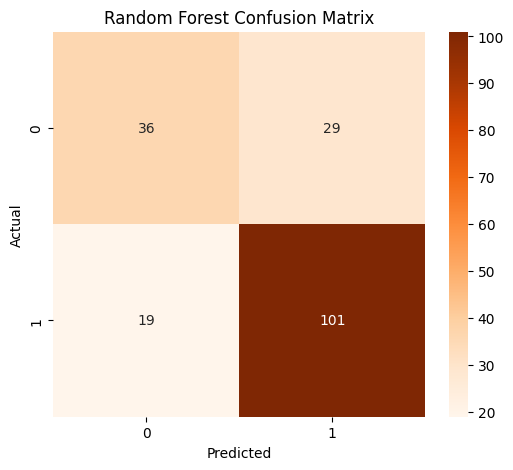

In [71]:
# ============================================
# SECTION 12 : RANDOM FOREST
# ============================================

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)

# Train
rf_model.fit(X_train, y_train)

# Predict
rf_pred = rf_model.predict(X_test)

# Probabilities
rf_prob = rf_model.predict_proba(X_test)[:,1]

# Metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

# RMSE
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

# Print
print("RANDOM FOREST RESULTS\n")

print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)
print("ROC AUC  :", rf_auc)
print("RMSE     :", rf_rmse)

# Report
print("\nClassification Report:\n")

print(classification_report(y_test, rf_pred))

# Save results
results.append([
    'Random Forest',
    rf_accuracy,
    rf_precision,
    rf_recall,
    rf_f1,
    rf_auc,
    rf_rmse
])

# ============================================
# RANDOM FOREST CONFUSION MATRIX
# ============================================
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# SECTION 13 — XGBOOST

In [72]:
!pip install xgboost

XGBOOST RESULTS

Accuracy : 0.7837837837837838
Precision: 0.8125
Recall   : 0.8666666666666667
F1 Score : 0.8387096774193549
ROC AUC  : 0.8238461538461538
RMSE     : 0.46499055497527714

Classification Report:

              precision    recall  f1-score   support

           0       0.72      0.63      0.67        65
           1       0.81      0.87      0.84       120

    accuracy                           0.78       185
   macro avg       0.77      0.75      0.76       185
weighted avg       0.78      0.78      0.78       185



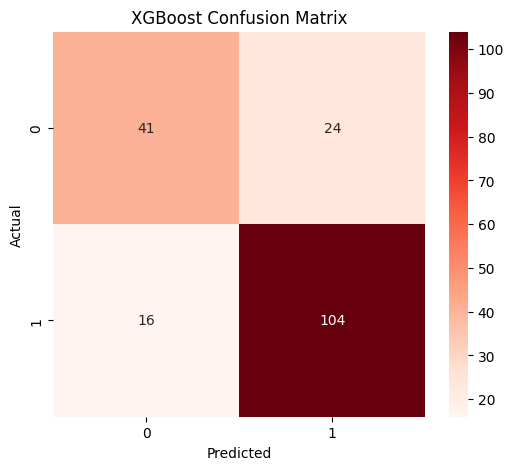

In [73]:
# ============================================
# SECTION 13 : XGBOOST
# ============================================

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

# Train
xgb_model.fit(X_train, y_train)

# Predict
xgb_pred = xgb_model.predict(X_test)

# Probabilities
xgb_prob = xgb_model.predict_proba(X_test)[:,1]

# Metrics
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_prob)

# RMSE
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

# Print
print("XGBOOST RESULTS\n")

print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1 Score :", xgb_f1)
print("ROC AUC  :", xgb_auc)
print("RMSE     :", xgb_rmse)

# Report
print("\nClassification Report:\n")

print(classification_report(y_test, xgb_pred))

# Save results
results.append([
    'XGBoost',
    xgb_accuracy,
    xgb_precision,
    xgb_recall,
    xgb_f1,
    xgb_auc,
    xgb_rmse
])

# ============================================
# XGBOOST CONFUSION MATRIX
# ============================================
cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds'
)

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# SECTION 14 — COMBINED ROC CURVE

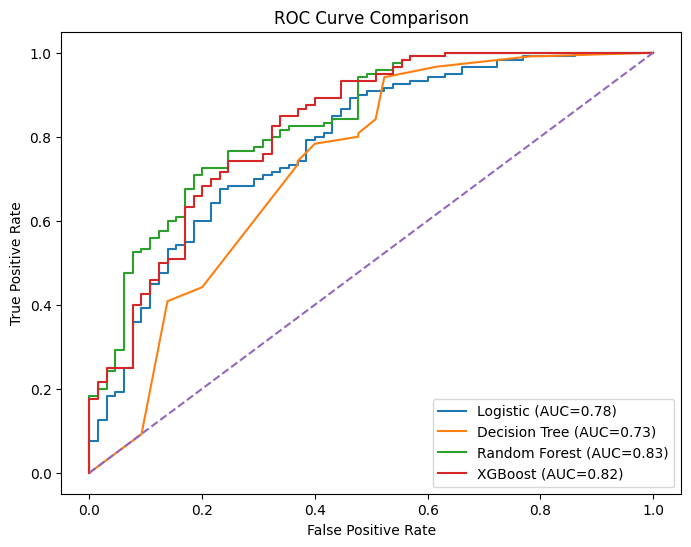

In [74]:
# ============================================
# SECTION 14 : COMBINED ROC CURVE
# ============================================

plt.figure(figsize=(8,6))

# Logistic
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
plt.plot(fpr_lr, tpr_lr,
         label=f'Logistic (AUC={lr_auc:.2f})')

# Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_prob)
plt.plot(fpr_dt, tpr_dt,
         label=f'Decision Tree (AUC={dt_auc:.2f})')

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
plt.plot(fpr_rf, tpr_rf,
         label=f'Random Forest (AUC={rf_auc:.2f})')

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)
plt.plot(fpr_xgb, tpr_xgb,
         label=f'XGBoost (AUC={xgb_auc:.2f})')

# Random line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

# SECTION 15 — AUTOMATIC COMPARISON TABLE

In [75]:
# ============================================
# SECTION 15 : COMPARISON TABLE
# ============================================

results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC-AUC',
        'RMSE'
    ]
)

results_df = results_df.sort_values(
    by='F1 Score',
    ascending=False
)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,RMSE
4,XGBoost,0.783784,0.812500,0.866667,0.838710,0.823846,0.464991
3,Random Forest,0.740541,0.776923,0.841667,0.808000,0.834231,0.509372
2,Random Forest,0.740541,0.776923,0.841667,0.808000,0.834231,0.509372
1,Decision Tree,0.702703,0.787611,0.741667,0.763948,0.733013,0.545250
0,Logistic Regression,0.702703,0.842105,0.666667,0.744186,0.783462,0.545250


# SECTION 16 — PERFORMANCE BAR PLOT

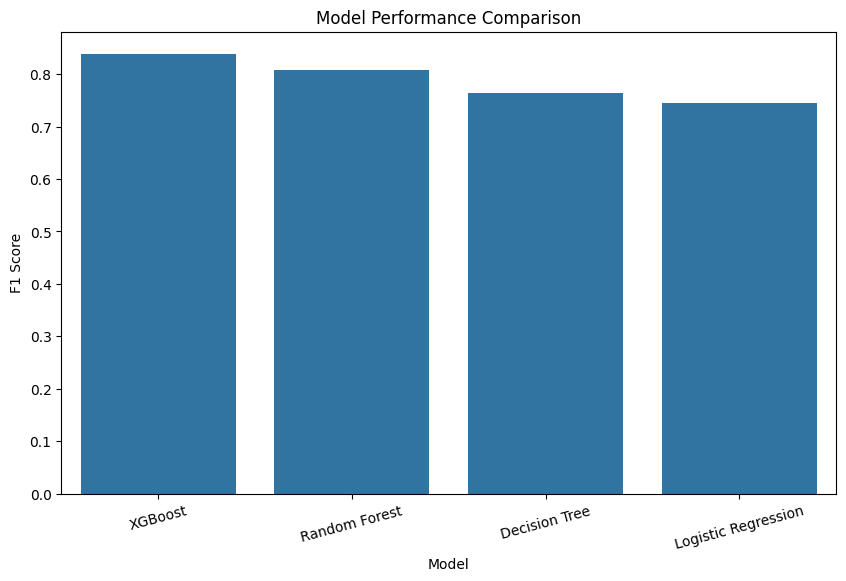

In [76]:
# ============================================
# SECTION 16 : PERFORMANCE BAR PLOT
# ============================================

plt.figure(figsize=(10,6))

sns.barplot(
    x='Model',
    y='F1 Score',
    data=results_df
)

plt.title("Model Performance Comparison")

plt.xticks(rotation=15)

plt.show()

#SECTION 17 — FEATURE IMPORTANCE

,Feature,Importance
6,relationships,0.139355
5,age_last_milestone_year,0.085833
4,age_first_milestone_year,0.065045
36,log_funding_total_usd,0.062214
34,milestone_efficiency,0.061401
33,funding_per_round,0.061303
2,age_first_funding_year,0.057877
3,age_last_funding_year,0.057695
8,funding_total_usd,0.056343
31,avg_participants,0.055946


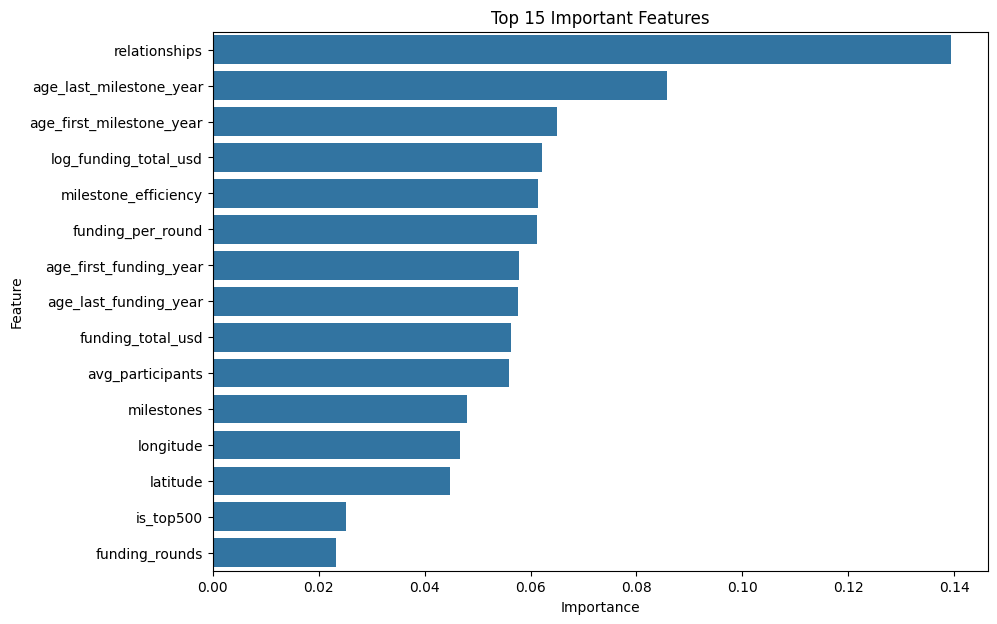

In [83]:
# ============================================
# RANDOM FOREST FEATURE IMPORTANCE
# ============================================

rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by='Importance',
    ascending=False
)

display(rf_importance.head(15))

# ============================================
# FEATURE IMPORTANCE PLOT
# ============================================

top_features = rf_importance.head(15)

plt.figure(figsize=(10,7))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title("Top 15 Important Features")

plt.show()

# SECTION 18 — HYPERPARAMETER TUNING

RANDOM FOREST TUNING

In [84]:
# ============================================
# SECTION 18 : RANDOM FOREST TUNING
# ============================================

rf_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight='balanced',
        random_state=42
    ),
    param_distributions=rf_params,
    n_iter=20,
    scoring='f1',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_

print("Best RF Parameters:\n")
print(rf_search.best_params_)

# ============================================
# TUNED RANDOM FOREST EVALUATION
# ============================================

rf_tuned_pred = best_rf.predict(X_test)

rf_tuned_prob = best_rf.predict_proba(X_test)[:,1]

# Metrics
rf_tuned_accuracy = accuracy_score(y_test, rf_tuned_pred)

rf_tuned_f1 = f1_score(y_test, rf_tuned_pred)

rf_tuned_auc = roc_auc_score(y_test, rf_tuned_prob)

print("TUNED RF ACCURACY:", rf_tuned_accuracy)
print("TUNED RF F1:", rf_tuned_f1)
print("TUNED RF ROC-AUC:", rf_tuned_auc)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best RF Parameters:

{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 15}
TUNED RF ACCURACY: 0.7621621621621621
TUNED RF F1: 0.819672131147541
TUNED RF ROC-AUC: 0.8337179487179487


XGBOOST TUNING

In [85]:
# ============================================
# XGBOOST TUNING
# ============================================

xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        eval_metric='logloss',
        random_state=42
    ),
    param_distributions=xgb_params,
    n_iter=20,
    scoring='f1',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_

print("Best XGBoost Parameters:\n")
print(xgb_search.best_params_)

# ============================================
# TUNED XGBOOST EVALUATION
# ============================================

xgb_tuned_pred = best_xgb.predict(X_test)

xgb_tuned_prob = best_xgb.predict_proba(X_test)[:,1]

# Metrics
xgb_tuned_accuracy = accuracy_score(y_test, xgb_tuned_pred)

xgb_tuned_f1 = f1_score(y_test, xgb_tuned_pred)

xgb_tuned_auc = roc_auc_score(y_test, xgb_tuned_prob)

print("TUNED XGB ACCURACY:", xgb_tuned_accuracy)
print("TUNED XGB F1:", xgb_tuned_f1)
print("TUNED XGB ROC-AUC:", xgb_tuned_auc)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best XGBoost Parameters:

{'subsample': 1.0, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
TUNED XGB ACCURACY: 0.8
TUNED XGB F1: 0.8549019607843137
TUNED XGB ROC-AUC: 0.8525641025641026


RANDOM FOREST FEATURE IMPORTANCE

#SECTION 19 — SAVE MODELS

In [86]:
# ============================================
# SECTION 19 : SAVE MODELS
# ============================================

joblib.dump(lr_model, 'logistic_model.pkl')

joblib.dump(dt_model, 'decision_tree_model.pkl')

joblib.dump(rf_model, 'random_forest_model.pkl')

joblib.dump(xgb_model, 'xgboost_model.pkl')

joblib.dump(best_rf, 'tuned_random_forest_model.pkl')

joblib.dump(best_xgb, 'tuned_xgboost_model.pkl')

print("All models saved successfully.")

All models saved successfully.


#SECTION 20 — ADVANCED STACKING MODEL

In [87]:
# ============================================
# ADVANCED STACKING ENSEMBLE
# ============================================

# Base learners
estimators = [
    ('rf', best_rf),
    ('xgb', best_xgb)
]

# Stacking classifier
stack_model = StackingClassifier(
    estimators=estimators,

    final_estimator=LogisticRegression(),

    stack_method='predict_proba',

    cv=5,

    passthrough=False,

    n_jobs=-1
)

# Train
stack_model.fit(X_train, y_train)

print("Advanced Stacking Model Trained.")

Advanced Stacking Model Trained.


# SECTION 21 — ADVANCED STACKING EVALUATION

In [88]:
# ============================================
# ADVANCED STACKING EVALUATION
# ============================================

# Predictions
stack_pred = stack_model.predict(X_test)

# Probabilities
stack_prob = stack_model.predict_proba(X_test)[:,1]

# Metrics
stack_accuracy = accuracy_score(y_test, stack_pred)

stack_precision = precision_score(y_test, stack_pred)

stack_recall = recall_score(y_test, stack_pred)

stack_f1 = f1_score(y_test, stack_pred)

stack_auc = roc_auc_score(y_test, stack_prob)

stack_rmse = np.sqrt(
    mean_squared_error(y_test, stack_pred)
)

# Results
print("ADVANCED STACKING RESULTS\n")

print("Accuracy :", stack_accuracy)

print("Precision:", stack_precision)

print("Recall   :", stack_recall)

print("F1 Score :", stack_f1)

print("ROC AUC  :", stack_auc)

print("RMSE     :", stack_rmse)

print("\nClassification Report:\n")

print(classification_report(y_test, stack_pred))

ADVANCED STACKING RESULTS

Accuracy : 0.7891891891891892
Precision: 0.8091603053435115
Recall   : 0.8833333333333333
F1 Score : 0.8446215139442231
ROC AUC  : 0.846923076923077
RMSE     : 0.45914138433690643

Classification Report:

              precision    recall  f1-score   support

           0       0.74      0.62      0.67        65
           1       0.81      0.88      0.84       120

    accuracy                           0.79       185
   macro avg       0.77      0.75      0.76       185
weighted avg       0.79      0.79      0.78       185



# SECTION 22 — ADVANCED STACKING CONFUSION MATRIX

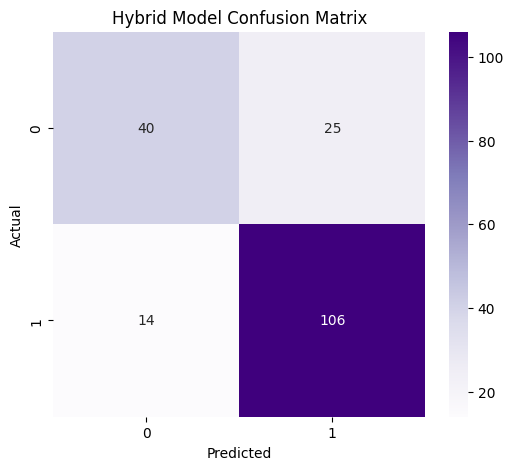

In [89]:
# ============================================
# HYBRID CONFUSION MATRIX
# ============================================

cm = confusion_matrix(y_test, stack_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples'
)

plt.title("Hybrid Model Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# SECTION 23 — ADVANCED STACKING ROC CURVE

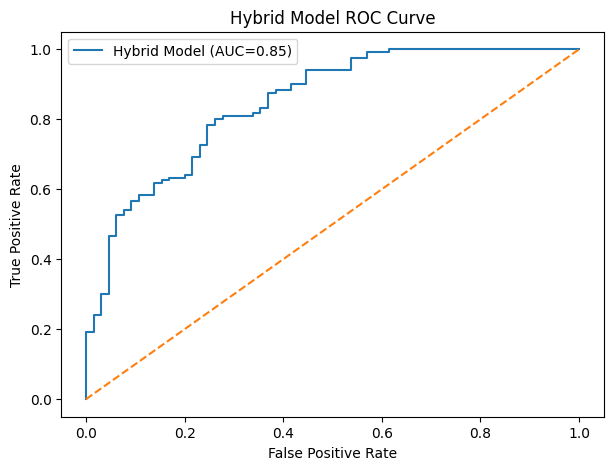

In [90]:
# ============================================
# HYBRID ROC CURVE
# ============================================

fpr_hybrid, tpr_hybrid, _ = roc_curve(
    y_test,
    stack_prob
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr_hybrid,
    tpr_hybrid,
    label=f'Hybrid Model (AUC={stack_auc:.2f})'
)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Hybrid Model ROC Curve")

plt.legend()

plt.show()

# SECTION 24 — FINAL COMPARISON TABLE

In [91]:
# ============================================
# UPDATED FINAL COMPARISON TABLE
# ============================================

advanced_results = pd.DataFrame([

    ['Logistic Regression',
     lr_accuracy,
     lr_precision,
     lr_recall,
     lr_f1,
     lr_auc,
     lr_rmse],

    ['Decision Tree',
     dt_accuracy,
     dt_precision,
     dt_recall,
     dt_f1,
     dt_auc,
     dt_rmse],

    ['Random Forest',
     rf_accuracy,
     rf_precision,
     rf_recall,
     rf_f1,
     rf_auc,
     rf_rmse],

     #['Tuned Random Forest',
     #rf_tuned_accuracy,
     #rf_precision,
     #rf_recall,
     #rf_tuned_f1,
     #rf_tuned_auc,
     #rf_rmse],

    ['XGBoost',
     xgb_accuracy,
     xgb_precision,
     xgb_recall,
     xgb_f1,
     xgb_auc,
     xgb_rmse],

     #['Tuned XGBoost',
     #xgb_tuned_accuracy,
     #xgb_precision,
     #xgb_recall,
     #xgb_tuned_f1,
     #xgb_tuned_auc,
     #xgb_rmse],

    ['Advanced Stacking',
     stack_accuracy,
     stack_precision,
     stack_recall,
     stack_f1,
     stack_auc,
     stack_rmse]

], columns=[
    'Model',
    'Accuracy',
    'Precision',
    'Recall',
    'F1 Score',
    'ROC-AUC',
    'RMSE'
])

advanced_results = advanced_results.sort_values(
    by='F1 Score',
    ascending=False
)

display(advanced_results)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,RMSE
4,Advanced Stacking,0.789189,0.809160,0.883333,0.844622,0.846923,0.459141
3,XGBoost,0.783784,0.812500,0.866667,0.838710,0.823846,0.464991
2,Random Forest,0.740541,0.776923,0.841667,0.808000,0.834231,0.509372
1,Decision Tree,0.702703,0.787611,0.741667,0.763948,0.733013,0.545250
0,Logistic Regression,0.702703,0.842105,0.666667,0.744186,0.783462,0.545250


# SECTION 25 — FINAL PERFORMANCE GRAPH

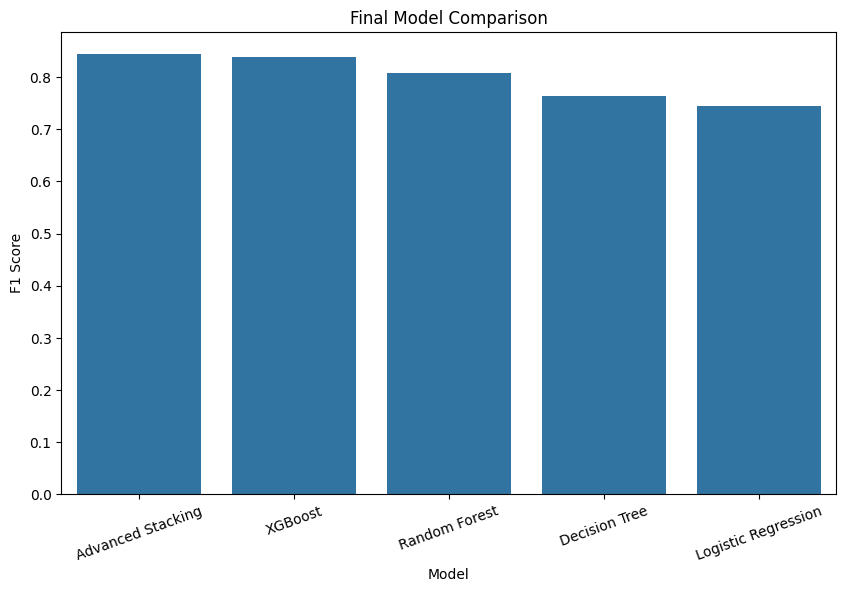

In [92]:
# ============================================
# FINAL PERFORMANCE GRAPH
# ============================================

plt.figure(figsize=(10,6))

sns.barplot(
    x='Model',
    y='F1 Score',
    data=advanced_results
)

plt.title("Final Model Comparison")

plt.xticks(rotation=20)

plt.show()

# SECTION 26 — INVESTMENT RECOMMENDATION SYSTEM

INVESTMENT RECOMMENDATION RESULTS



,Actual_Status,Predicted_Status,Success_Probability,Investment_Recommendation
0,Acquired,Acquired,0.847506,Moderate Invest
1,Acquired,Acquired,0.842487,Moderate Invest
2,Acquired,Acquired,0.816809,Moderate Invest
3,Closed,Closed,0.128947,Avoid
4,Acquired,Acquired,0.882423,Strong Invest
5,Acquired,Acquired,0.508423,High Risk
6,Acquired,Acquired,0.859667,Strong Invest
7,Closed,Acquired,0.741122,Moderate Invest
8,Acquired,Closed,0.302240,Avoid
9,Closed,Acquired,0.756701,Moderate Invest


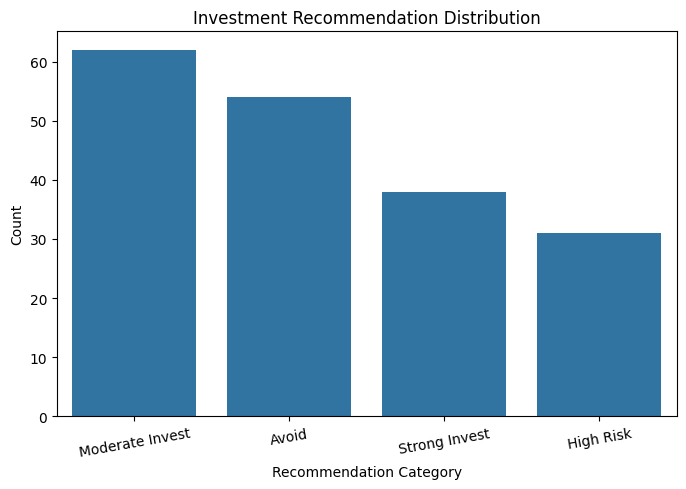

In [95]:
# ============================================
# SECTION 26 : INVESTMENT RECOMMENDATION SYSTEM
# ============================================

# Function to convert probability into recommendation
def investment_recommendation(probability):

    if probability >= 0.85:
        return "Strong Invest"

    elif probability >= 0.70:
        return "Moderate Invest"

    elif probability >= 0.50:
        return "High Risk"

    else:
        return "Avoid"


# ============================================
# CREATE RECOMMENDATION DATAFRAME
# ============================================

recommendation_df = pd.DataFrame({

    'Actual_Status': y_test.values,

    'Predicted_Status': stack_pred,

    'Success_Probability': stack_prob

})


# Convert numerical labels into readable text
recommendation_df['Actual_Status'] = recommendation_df[
    'Actual_Status'
].map({
    1: 'Acquired',
    0: 'Closed'
})

recommendation_df['Predicted_Status'] = recommendation_df[
    'Predicted_Status'
].map({
    1: 'Acquired',
    0: 'Closed'
})


# Generate investment recommendations
recommendation_df['Investment_Recommendation'] = recommendation_df[
    'Success_Probability'
].apply(investment_recommendation)


# ============================================
# DISPLAY SAMPLE RESULTS
# ============================================

print("INVESTMENT RECOMMENDATION RESULTS\n")

display(recommendation_df.head(15))


# ============================================
# RECOMMENDATION DISTRIBUTION GRAPH
# ============================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='Investment_Recommendation',
    data=recommendation_df
)

plt.title("Investment Recommendation Distribution")

plt.xlabel("Recommendation Category")

plt.ylabel("Count")

plt.xticks(rotation=10)

plt.show()

#SECTION 27 — Save Final Hybrid Model

In [96]:
# ============================================
# SECTION 27 : SAVE FINAL HYBRID MODEL
# ============================================

# Save Advanced Stacking Model
joblib.dump(
    stack_model,
    'advanced_stacking_model.pkl'
)

# Save Scaler
joblib.dump(
    scaler,
    'scaler.pkl'
)

# Save Feature Names
joblib.dump(
    X.columns.tolist(),
    'feature_names.pkl'
)

# Save Recommendation Data
recommendation_df.to_csv(
    'investment_recommendations.csv',
    index=False
)

print("===================================")
print("FINAL MODELS SAVED SUCCESSFULLY")
print("===================================")

print("\nSaved Files:")

print("1. advanced_stacking_model.pkl")
print("2. scaler.pkl")
print("3. feature_names.pkl")
print("4. investment_recommendations.csv")

FINAL MODELS SAVED SUCCESSFULLY

Saved Files:
1. advanced_stacking_model.pkl
2. scaler.pkl
3. feature_names.pkl
4. investment_recommendations.csv
